# Building a random network from scratch — a tour of `Network`'s conventions

Every preset in `g2elin_core.network.presets` is hand-transcribed from a
MATLAB source and satisfies the schema's structural conventions *by
construction*. This notebook goes the other way: it builds a `Network`
**programmatically**, from a random topology, using nothing but the raw
schema types (`Bus`, `Line`, `Transformer`, `Load`, `DerUnit`) — the same
building blocks the web UI's drag-and-drop canvas builder uses, and the
same building blocks any script that generates test cases would use.

The point isn't the random network itself (it's a throwaway topology, not
a physically meaningful case study) — it's the *process* of building one
correctly, and what happens when you don't. Two validation layers are
exercised along the way:

1. **`Network`'s own pydantic validators** — enforced unconditionally,
   every time a `Network` is constructed: every bus reference must
   resolve, and there must be exactly one slack DER unit. You cannot
   construct an instance that violates these; the exception happens at
   `Network(...)` itself.
2. **`network.validation.validate_network()`** — a further, opt-in check
   for everything *syntactically* valid but still structurally wrong:
   a DER not sitting behind its own transformer, a line or load landing
   directly on a DER's private bus, a disconnected network, and so on.
   These are easy to produce by construction (especially programmatically
   or via drag-and-drop) and would otherwise surface as a bare crash deep
   inside power flow, modal analysis, or EMT — see
   `docs/sphinx/modules/network.md`'s "Validation" section for the full
   account of why this module exists.

We'll build one clean random network the right way, run the full analysis
pipeline on it, then deliberately break several copies of it to see
exactly what each validation layer catches — and close with a batch of
many random networks to show the builder is robust across sizes and
seeds, not just one lucky draw.

In [72]:
%matplotlib inline
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)

from g2elin_core.network.schema import (
    Bus, Line, Transformer, Load, DerUnit, Network, BusType, UnitType, GfmController,
)
from g2elin_core.network.validation import validate_network
from g2elin_core.network.topology import compute_topology_layout
from g2elin_core.powerflow import run_power_flow
from g2elin_core.pipeline import linearize_network
from g2elin_core.modal import analyze

RNG_SEED = 42

## Run-time toggles

Section 6 (nonlinear EMT simulation) and Section 7 (region-of-attraction
tracing) are the slowest cells in this notebook -- each is a full
*nonlinear* coupled-Newton time integration, not just linear algebra.
Both default to **off** so "Restart Kernel and Run All" finishes quickly;
flip either flag to `True` and re-run to actually exercise that section.

In [73]:
RUN_EMT_SECTION = True  # Section 6: nonlinear EMT time-domain simulation
RUN_ROA_SECTION = False  # Section 7: region-of-attraction grid tracing

## 1. The convention a network builder has to respect

Paraphrasing `network.md`'s Validation section, and matching
`Functions/network_form.m`'s original MATLAB convention:

- Every DER unit (`sm`/`gfm`/`gfl`/`infinite_bus`) sits on **its own
  private bus**, reached from the rest of the network through **exactly
  one transformer** — never a `Line`, never shared with another DER, never
  another transformer's `hv_bus`.
- A DER's own local consumption is its `p_cons_mw`/`q_cons_mvar` fields,
  not a separate `Load` on its private bus.
- **Exactly one** DER unit has `bus_type = slack`, and for modal
  analysis/EMT/ROA to work it should be an `sm` or `infinite_bus` (a
  `gfm`/`gfl` slack is accepted for power flow but not wired into
  `interconnect.network_assembly` yet — `validate_network()` flags this
  as a warning, not an error).
- The whole graph (buses + lines + transformers) must be **connected** —
  every bus must be reachable from the slack.

None of that is specific to any one topology *shape* — a schema-valid
network can be meshed or radial, tiny or large, one DER or twenty. The
builder below picks a specific, deliberately realistic shape on top of
those rules: a **radial** (tree — no loops) feeder of at least 15 buses,
carrying exactly **2 SM + 2 GFM + 2 GFL**, each tapping a *different*
point on the feeder (no two DERs ever share a connection point) — the
kind of topology and DER mix an actual distribution-feeder hosting-
capacity study would look at, not just the smallest schema-valid
example. Every rule above is still enforced explicitly, with a comment
at each step naming which one.

In [74]:
def random_network(
    rng: np.random.Generator,
    n_grid_buses: int = 15,
    load_fraction: float = 0.6,
    sn_mva: float = 100.0,
    f_hz: float = 60.0,
    hv_kv: float = 230.0,
    lv_kv: float = 18.0,
    name: str | None = None,
) -> Network:
    '''A random, but *convention-respecting*, network: a random RADIAL
    (tree-topology -- no loops) grid at ``hv_kv`` with at least 15 buses,
    random loads on a subset of them, and exactly 2 SM + 2 GFM + 2 GFL
    DER units (the first SM forced to the slack) each on its own new bus
    at ``lv_kv``, reached by its own transformer -- and each connected to
    a *different* grid bus, so no two DERs ever share a connection point.
    '''
    if n_grid_buses < 15:
        raise ValueError(f"n_grid_buses must be >= 15 (need room for 6 non-colliding DER taps), got {n_grid_buses}")

    grid_bus_ids = list(range(1, n_grid_buses + 1))
    buses = [Bus(id=i, name=f"bus{i}", vn_kv=hv_kv) for i in grid_bus_ids]

    # Radial rule: the grid topology *is* a random spanning tree, full
    # stop -- nothing added on top. A tree has exactly n-1 edges and, by
    # construction, no cycles, which is exactly what "radial" means for a
    # feeder (as opposed to a meshed transmission network) -- and it
    # still guarantees every bus is reachable from every other one, the
    # same connectivity rule a meshed topology would also have to satisfy.
    tree_seed = int(rng.integers(0, 2**31 - 1))
    tree = nx.random_labeled_tree(n_grid_buses, seed=tree_seed)
    edges = sorted((min(u, v) + 1, max(u, v) + 1) for u, v in tree.edges())

    # Distribution-feeder-scale impedance (matching CIGRE_raw.m's own
    # per-line r_pu/x_pu order of magnitude), not the WSCC-style
    # transmission-line values an earlier version of this builder used --
    # those were tuned for a handful of buses with redundant paths; a
    # purely radial chain of 15+ buses has no redundant path to share
    # current with, so a single hop's impedance accumulates all the way
    # down the tree. At transmission-line scale that accumulation
    # regularly pushed power flow to non-convergence on the larger/longer
    # trees this builder can now draw; at this scale it didn't, across 50
    # test seeds (see the notebook's own Section 10 for the same claim
    # exercised in-line, not just asserted here).
    lines = [
        Line(
            from_bus=u, to_bus=v,
            r_pu=round(float(rng.uniform(0.001, 0.008)), 4),
            x_pu=round(float(rng.uniform(0.003, 0.02)), 4),
            b_pu=round(float(rng.uniform(0.001, 0.02)), 4),
            length_km=round(float(rng.uniform(1.0, 20.0)), 1),
            name=f"line_{u}_{v}",
        )
        for u, v in edges
    ]

    # Exactly 2 SM + 2 GFM + 2 GFL, in this fixed order -- der id 1 is
    # always the slack SM (a supported slack type; see
    # validate_network()'s own warning for what happens if a GFM/GFL ends
    # up there instead).
    der_spec = [
        (UnitType.SYNCHRONOUS_MACHINE, BusType.SLACK),
        (UnitType.SYNCHRONOUS_MACHINE, BusType.PV),
        (UnitType.GFM, BusType.PV),
        (UnitType.GFM, BusType.PV),
        (UnitType.GFL, BusType.PQ),
        (UnitType.GFL, BusType.PQ),
    ]
    n_der = len(der_spec)

    # DER placement: one new private bus + one dedicated transformer per
    # unit, id'd past every grid bus id -- never touched by a Line/Load/
    # another Transformer above. `replace=False` is the "no two DERs
    # connected to the same node" rule -- each of the 6 taps lands on its
    # own distinct grid bus, never two DERs sharing one.
    der_bus_ids = [n_grid_buses + 1 + k for k in range(n_der)]
    der_buses = [Bus(id=b, name=f"der{k + 1}_terminal", vn_kv=lv_kv) for k, b in enumerate(der_bus_ids)]
    dispatch_buses = rng.choice(grid_bus_ids, size=n_der, replace=False)

    der_units: list[DerUnit] = []
    transformers: list[Transformer] = []
    p_set_by_der: list[float] = []
    for k, (der_bus, dispatch_bus, (unit_type, bus_type)) in enumerate(zip(der_bus_ids, dispatch_buses, der_spec)):
        controller = GfmController.DROOP if unit_type == UnitType.GFM else None
        xd_pu = round(float(rng.uniform(0.15, 0.28)), 3) if unit_type == UnitType.SYNCHRONOUS_MACHINE else None
        # Dispatch (P_set) is decided here, before loads, so total load
        # can be sized as a *fraction of total dispatched generation*
        # below -- an arbitrary flat load range would routinely exceed
        # what 6 random DERs can actually supply and leave power flow
        # infeasible, which isn't a schema-convention issue but would
        # make the rest of this notebook's random draws unusable.
        p_set_mw = round(float(rng.uniform(0.5, 1.0) * sn_mva), 1)
        p_set_by_der.append(p_set_mw)

        der_units.append(DerUnit(
            id=k + 1, bus=der_bus, unit_type=unit_type, bus_type=bus_type,
            v_set_pu=round(float(rng.uniform(0.98, 1.03)), 3),
            p_set_mw=p_set_mw,
            q_set_mvar=0.0,
            p_cons_mw=round(0.001 * sn_mva, 3),  # own consumption -- never a separate Load
            controller=controller, xd_pu=xd_pu,
        ))
        transformers.append(Transformer(
            hv_bus=int(dispatch_bus), lv_bus=der_bus,  # -- always dispatch (grid) bus -> DER's own bus
            r_pu=0.0, x_pu=round(float(rng.uniform(0.05, 0.09)), 4),
            sn_mva=sn_mva, name=f"der{k + 1}_xfmr",
        ))

    # Loads only ever reference a *grid* bus -- never a DER's own bus.
    # Sized as a fraction of total dispatched generation (leaving the
    # slack real headroom to balance losses), split across the chosen
    # load buses with a Dirichlet draw so shares vary but always sum to
    # the target total.
    load_bus_ids = [b for b in grid_bus_ids if rng.random() < load_fraction] or [grid_bus_ids[0]]
    # A floor on both P and Q (not just fine rounding) matters once there
    # can be 15+ load buses splitting one Dirichlet draw: a bus landing on
    # a tiny share is real, but a *rounded-to-zero* Q would make that
    # load's equivalent reactance (operating_point.py's load_rx -> Lc in
    # components/load.py) exactly zero -- a division by zero inside the
    # linearizer's Jacobian, surfacing as a cryptic "cannot convert
    # complex to float" (sympy's `zoo` for 1/0) instead of anything about
    # the actual load. A strictly-positive floor makes that categorically
    # impossible rather than merely unlikely.
    total_load_mw = sum(p_set_by_der) * float(rng.uniform(0.5, 0.7))
    shares = rng.dirichlet(np.ones(len(load_bus_ids)))
    loads = [
        Load(
            bus=b,
            p_mw=round(max(total_load_mw * share, 0.05), 4),
            q_mvar=round(max(total_load_mw * share * float(rng.uniform(0.2, 0.35)), 0.01), 4),
            name=f"load_bus{b}",
        )
        for b, share in zip(load_bus_ids, shares)
    ]

    return Network(
        name=name or f"random_radial_{n_grid_buses}bus_2sm_2gfm_2gfl",
        f_hz=f_hz, sn_mva=sn_mva,
        buses=buses + der_buses, lines=lines, transformers=transformers,
        loads=loads, der_units=der_units,
    )

## 2. Build one, and look at it

`Network(...)`'s own pydantic validators already ran inside the builder
above (bus refs resolve, exactly one slack) -- if either had been
violated, the exception would already have happened before this cell.

In [75]:
rng = np.random.default_rng(RNG_SEED)
net = random_network(rng)

print(net.name, f"-- {net.f_hz} Hz, {net.sn_mva} MVA base")
print(f"{len(net.buses)} buses, {len(net.lines)} lines, {len(net.transformers)} transformers, "
      f"{len(net.loads)} loads, {len(net.der_units)} DER units")
for der in net.der_units:
    tag = " (SLACK)" if der.bus_type == BusType.SLACK else ""
    print(f"  DER {der.id}: {der.unit_type.value:12s} bus={der.bus:2d} bus_type={der.bus_type.value:5s}"
          f" P_set={der.p_set_mw:7.2f} MW{tag}")

random_radial_15bus_2sm_2gfm_2gfl -- 60.0 Hz, 100.0 MVA base
21 buses, 14 lines, 6 transformers, 11 loads, 6 DER units
  DER 1: sm           bus=16 bus_type=slack P_set=  88.20 MW (SLACK)
  DER 2: sm           bus=17 bus_type=pv    P_set=  65.20 MW
  DER 3: gfm          bus=18 bus_type=pv    P_set=  60.70 MW
  DER 4: gfm          bus=19 bus_type=pv    P_set=  61.70 MW
  DER 5: gfl          bus=20 bus_type=pq    P_set=  64.70 MW
  DER 6: gfl          bus=21 bus_type=pq    P_set=  89.20 MW


## 3. `validate_network()` — the cheap pre-flight check

This is the same check the web UI's network editor calls on every edit,
and the same one `compute_operating_point()` runs automatically before
doing any real work. On a network built to respect the convention, it
comes back clean.

In [76]:
issues = validate_network(net)
print("ok:" , not any(i.severity == "error" for i in issues), " -- ", len(issues), "issue(s)")
for i in issues:
    print(f"  [{i.severity}] {i.message}")

ok: True  --  0 issue(s)


## 4. Topology, power flow, modal analysis

Exactly the same three calls the tour notebook uses on the hand-written
presets -- nothing about them is preset-specific, they operate on any
`Network`.

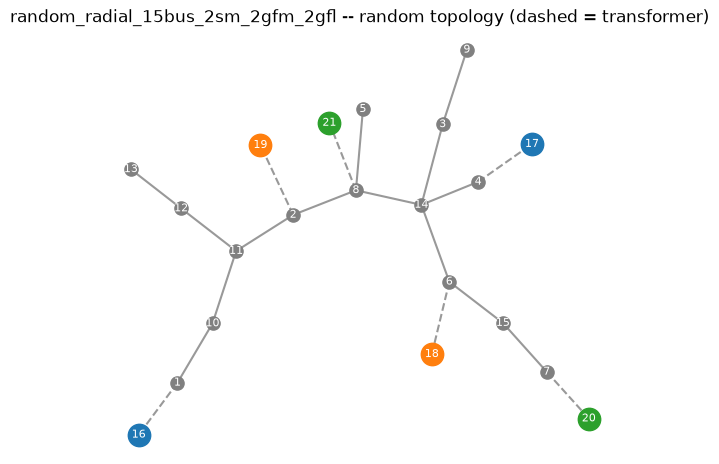

In [77]:
topo = compute_topology_layout(net)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
pos = {n.id: (n.x, n.y) for n in topo.nodes}
for e in topo.edges:
    x1, y1 = pos[e.from_bus]
    x2, y2 = pos[e.to_bus]
    style = "--" if e.kind == "transformer" else "-"
    ax.plot([x1, x2], [y1, y2], style, color="0.6", zorder=1)
colors = {"sm": "tab:blue", "gfm": "tab:orange", "gfl": "tab:green", "infinite_bus": "tab:red", None: "0.5"}
for n in topo.nodes:
    ax.scatter(*pos[n.id], s=260 if n.unit_type else 90, color=colors[n.unit_type], zorder=2)
    ax.annotate(f"{n.id}", pos[n.id], ha="center", va="center", fontsize=8, color="white", zorder=3)
ax.set_title(f"{net.name} -- random topology (dashed = transformer)")
ax.set_axis_off()
plt.show()

In [78]:
pf = run_power_flow(net)
print("converged:", pf.converged, " total losses:", round(pf.total_losses_mw(), 4), "MW")
pf.bus_table().head()

converged: True  total losses: 4.1313 MW


,bus,vm_pu,va_degree,p_net_gen_mw,q_net_gen_mvar
0,1,0.9760,4.7941,-0.0000,-0.0000
1,2,0.9800,7.8786,-7.8553,-2.6346
2,3,0.9765,8.6524,-35.1284,-9.4273
3,4,0.9816,9.8735,-15.7376,-3.6252
4,5,0.9824,8.9588,-0.0000,-0.0000


176 states -- 0 genuinely unstable mode(s), max Re(lambda) = -0.0000


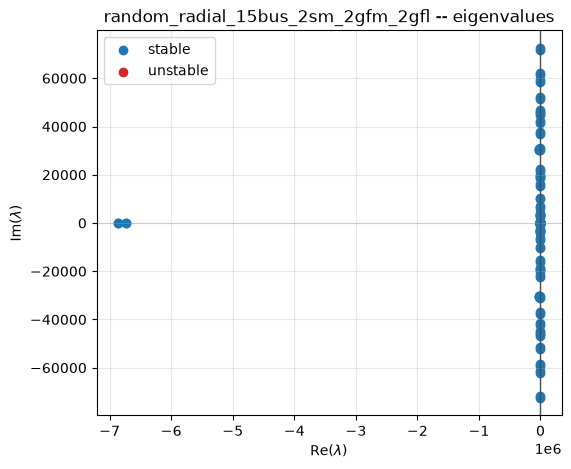

,mode,real,imag,undamped_hz,damped_hz,damping_pct,state1,part1_pct,state2,part2_pct,state3,part3_pct
175,175,-5.4881e-11,0.000,8.7346e-12,0.0000,100.0000,theta_{SM_1},25.6098,theta_{GFM_2},25.3387,theta_{SM_2},24.6553
174,174,-1.8487e-01,0.000,2.9424e-02,0.0000,100.0000,v_pss_{SM_1},87.8565,v_pss_{SM_2},11.5185,v_2_{SM_1},0.1837
173,173,-1.8542e-01,0.000,2.9510e-02,0.0000,100.0000,v_pss_{SM_2},87.9750,v_pss_{SM_1},11.4899,v_2_{SM_2},0.1374
172,172,-4.9832e-01,0.000,7.9310e-02,0.0000,100.0000,v_1_{SM_1},94.2082,v_1_{SM_2},3.6103,v_2_{SM_1},0.9614
171,171,-5.0354e-01,0.000,8.0140e-02,0.0000,100.0000,v_1_{SM_2},91.4336,v_1_{SM_1},3.4696,v_2_{SM_2},1.9056
170,170,-9.9586e-01,0.000,1.5850e-01,0.0000,100.0000,psi_1q_{SM_2},42.2034,theta_{SM_2},20.4810,psi_2q_{SM_2},5.4101
169,169,-1.6056e+00,0.000,2.5554e-01,0.0000,100.0000,psi_1q_{SM_1},70.7106,theta_{SM_1},6.6197,psi_2q_{SM_1},4.8560
160,160,-3.1643e+00,0.000,5.0362e-01,0.0000,100.0000,psi_1q_{SM_2},27.7581,P_m_{SM_2},18.6199,P_m_{SM_1},16.3948
163,163,-2.4422e+00,3.871,7.2845e-01,0.6161,53.3586,psi_fd_{SM_2},27.0509,e_fd_{SM_2},23.9205,e_3_{SM_2},12.8903
164,164,-2.4422e+00,-3.871,7.2845e-01,0.6161,53.3586,psi_fd_{SM_2},27.0509,e_fd_{SM_2},23.9205,e_3_{SM_2},12.8903


In [79]:
system = linearize_network(net, pf)
modal = analyze(system.A, system.state_names)
# A strict "< 0" reads as False for *every* network built by this
# codebase, not just this one -- every closed-loop system here has one
# eigenvalue structurally pinned to ~0 (the free reference-angle/"theta
# problem" direction; see docs/sphinx/modules/stability.md), not a real
# instability. A small tolerance separates that from a genuine unstable
# mode.
n_unstable = int(np.sum(modal.eigenvalues.real > 1e-6))
print(f"{system.A.shape[0]} states -- {n_unstable} genuinely unstable mode(s), "
      f"max Re(lambda) = {modal.eigenvalues.real.max():.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
stable = modal.eigenvalues.real < 1e-6
ax.scatter(modal.eigenvalues.real[stable], modal.eigenvalues.imag[stable], color="tab:blue", label="stable")
ax.scatter(modal.eigenvalues.real[~stable], modal.eigenvalues.imag[~stable], color="tab:red", label="unstable")
ax.axvline(0, color="0.3", lw=1)
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r"Re($\lambda$)"); ax.set_ylabel(r"Im($\lambda$)")
ax.set_title(f"{net.name} -- eigenvalues")
ax.legend()
plt.show()

modal.summary_table().sort_values("undamped_hz").head(10)

## 5. `modal.toolbox` — every option

`modal.toolbox` has four functions, all pure linear algebra on the
eigendecomposition already computed above (no new solve) — this section
exercises every one of them, not just a curated subset:

- **`eigenvalue_sensitivity(modal, A, mode, n_top=8)`** — how sensitive
  one mode's own eigenvalue is to each structurally-nonzero entry of $A$
  (Kundur's own sensitivity result, $\partial\lambda_i/\partial A_{kj} =
  w_i[k]v_i[j]$).
- **`mode_shape(modal, mode, n_top=5)`** — relative phase between a
  mode's own top participating states.
- **`free_response(modal, perturb_index, offset, t)`** — closed-form
  response to an initial-condition perturbation.
- **`step_response(system, input_name, output_name, amplitude, t)`** —
  MIMO step response between one chosen input/output pair.

All four need one specific mode to look at -- picking the mode with the
*highest raw participation* from `dw_r_` (a synchronous machine's own
speed deviation) finds the network's electromechanical swing mode
directly, rather than accidentally landing on the network's own
structurally-near-zero reference-angle mode (see the eigenvalue-map cell
above and `docs/sphinx/modules/stability.md`'s "theta problem" note --
that mode is real but isn't an oscillation to look at with any of the
four functions below).

In [80]:
from g2elin_core.modal.toolbox import eigenvalue_sensitivity, mode_shape, free_response, step_response

summary = modal.summary_table()
swing = summary[summary["state1"].str.contains("dw_r_")].sort_values("damping_pct").iloc[0]
mode_idx = int(swing["mode"])
print(f"Swing mode: #{mode_idx}, {swing['damped_hz']:.3f} Hz, {swing['damping_pct']:.1f}% damping, "
      f"top state: {swing['state1']} ({swing['part1_pct']:.1f}%)")

sens = eigenvalue_sensitivity(modal, system.A, mode_idx, n_top=8)
print(f"\nTop {len(sens.top)} entries A is most sensitive to:")
for entry in sens.top:
    print(f"  d(lambda)/d(A[{entry.row_state}, {entry.col_state}]) = {entry.value:.4f}")

Swing mode: #168, 2.095 Hz, 12.8% damping, top state: dw_r_{SM_1} (28.1%)

Top 8 entries A is most sensitive to:
  d(lambda)/d(A[dw_r_{SM_1}, P_m_{SM_1}]) = 25.3649
  d(lambda)/d(A[dw_r_{SM_2}, P_m_{SM_2}]) = 14.5631
  d(lambda)/d(A[dw_r_{SM_2}, i_gd_{SM_2}]) = 11.3657
  d(lambda)/d(A[dw_r_{SM_1}, psi_d_{SM_1}]) = 5.9861
  d(lambda)/d(A[dw_r_{SM_1}, psi_q_{SM_1}]) = 4.1213
  d(lambda)/d(A[dw_r_{SM_1}, psi_1d_{SM_1}]) = 3.3568
  d(lambda)/d(A[dw_r_{SM_2}, psi_d_{SM_2}]) = 3.1249
  d(lambda)/d(A[dw_r_{SM_1}, psi_2q_{SM_1}]) = 3.1057


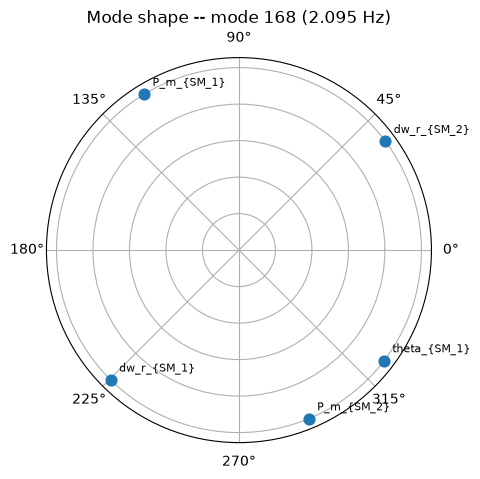

In [81]:
shape = mode_shape(modal, mode_idx, n_top=5)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})
angles = np.radians(shape.angles_deg)
ax.scatter(angles, [1] * len(angles), s=60, color="tab:blue", zorder=3)
for a, name in zip(angles, shape.states):
    ax.annotate(name, (a, 1), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_yticklabels([])
ax.set_title(f"Mode shape -- mode {mode_idx} ({swing['damped_hz']:.3f} Hz)")
plt.show()

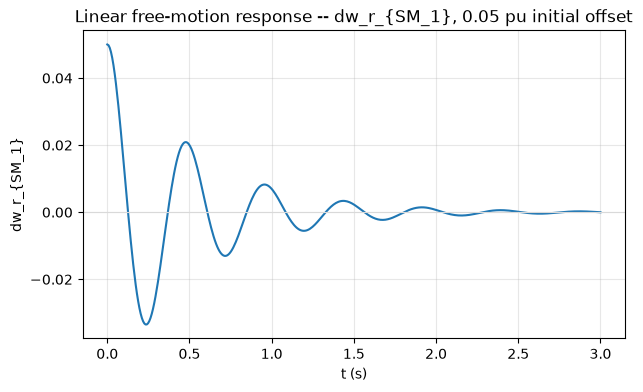

In [82]:
perturb_name = swing["state1"]
perturb_idx = system.state_names.index(perturb_name)
t = np.linspace(0, 3.0, 400)
x_lin = free_response(modal, perturb_idx, offset=0.05, t=t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, x_lin[perturb_idx, :], color="tab:blue")
ax.axhline(0, color="0.85", lw=0.8)
ax.set_xlabel("t (s)"); ax.set_ylabel(perturb_name)
ax.set_title(f"Linear free-motion response -- {perturb_name}, 0.05 pu initial offset")
ax.grid(True, alpha=0.3)
plt.show()

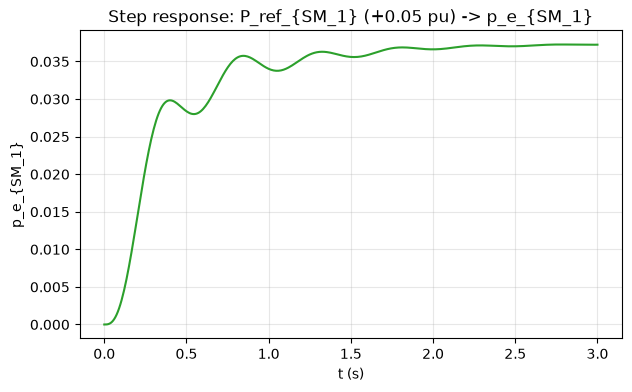

In [83]:
sm_input = next(n for n in system.input_names if n.startswith("P_ref_{SM"))
sm_output = next(n for n in system.output_names if n.startswith("p_e_{SM"))
y_step = step_response(system, sm_input, sm_output, amplitude=0.05, t=t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, y_step, color="tab:green")
ax.set_xlabel("t (s)"); ax.set_ylabel(sm_output)
ax.set_title(f"Step response: {sm_input} (+0.05 pu) -> {sm_output}")
ax.grid(True, alpha=0.3)
plt.show()

## 6. Nonlinear EMT simulation — every option

`timedomain.emt.simulate()` integrates the network's *actual* nonlinear
differential-algebraic equations (a coupled Newton solve at every
timestep) instead of the linearized $A$ matrix above. Building the model
(assembling blocks, no integration yet) is cheap, so it stays
unconditional -- Section 7's ROA sweep also needs `model`, regardless of
`RUN_EMT_SECTION`.

**Every option `simulate()` takes**, not just the ones this notebook
happens to use:

| Parameter | Meaning |
|---|---|
| `t_span` | `(t0, t_final)` — the integration window |
| `x0` | Initial state; defaults to the model's own operating point |
| `u_exo_fn` | `t -> exogenous-input vector` — drives a disturbance by changing a *reference* over time, instead of (or in addition to) perturbing a state; defaults to holding it fixed |
| `t_eval` | Explicit sample times to return; defaults to the solver's own adaptive steps |
| `method` | `scipy.integrate.solve_ivp`'s integrator — default `"Radau"` (implicit, L-stable — this system's stiffest modes reach ~$10^6$–$10^7$ rad/s); `"BDF"`/`"LSODA"` are other implicit options, explicit methods (`"RK45"`) aren't recommended for a system this stiff |
| `rtol` / `atol` | Relative/absolute integration tolerance |
| `first_step` | Initial step size hint; a tiny value (e.g. `1e-8`) helps the solver get past the sharp initial algebraic-consistency transient every trajectory starts with |

Two demonstrations follow: perturbing a **state** (an initial-condition
offset) and perturbing an **input** via `u_exo_fn` (a permanent step in
an exogenous reference, held from $t=0$) — the same `perturb_kind`
choice the web UI's EMT tab exposes.

In [84]:
from g2elin_core.timedomain.emt import build_nonlinear_network, simulate

model = build_nonlinear_network(net, pf)
print(f"nonlinear model: {len(model.state_names)} states, {len(model.input_names)} inputs, "
      f"{len(model.output_names)} outputs")

nonlinear model: 176 states, 22 inputs, 28 outputs


### 6a. Perturbing a state — traced live, step by step

`simulate()` (Section 6's own `t_eval`/`method`/... table above) is a
one-shot call: `scipy.integrate.solve_ivp` runs straight through to
completion and only returns the finished trajectory, with no way to
watch it happen. Getting a genuinely *live* trace means bypassing that
convenience wrapper and driving `scipy.integrate.Radau`'s own low-level
stepper object directly — the same algorithm, called one step at a time
instead of all at once, redrawing an external plot window after each
step.

**This still isn't a literal fixed timestep** — Radau is an *adaptive*
implicit method; there is no mode where it takes uniformly-sized steps.
`max_step` below is the honest equivalent of "a specified fixed step
value" for an adaptive solver: it caps how large any single step (and so
any single redraw) is allowed to get, without forcing every step to
actually be that size — the solver can still take *smaller* steps than
`max_step` where the dynamics demand it (e.g. through the sharp initial
transient), it just can never take a *larger* one.

**The live window itself won't appear in this saved notebook.** Unlike
an inline `plt.show()`, an external window isn't something `nbconvert
--execute`'s headless run (or the Sphinx-embedded copy of this notebook)
can capture — Part 2 below re-plots the same result as a normal embedded
static figure once the live run finishes, so the comparison is still
visible either way. The live window only shows up if you run this cell
yourself, in a live kernel.

In [85]:
if RUN_EMT_SECTION:
    import scipy.integrate

    x0 = model.initial_state()
    xp = x0.copy()
    xp[perturb_idx] += 0.05

    t_final = 1.5
    max_step = 0.01  # caps the adaptive solver's own step -- see the markdown above

    # The same warm-started coupled-algebraic-solve pattern simulate() itself uses
    # internally (g2elin_core/timedomain/emt.py) -- replicated by hand here because
    # solve_ivp() can't yield control back between steps; the OOP stepper can.
    u_exo_default = model.default_u_exo()
    z_guess, u_guess = model.initial_algebraic_guess()
    cache = {"z": z_guess, "u": u_guess}

    def rhs_fn(t, x):
        xdot, z_sol, u_sol = model.rhs(x, u_exo_default, cache["z"], cache["u"])
        cache["z"], cache["u"] = z_sol, u_sol
        return xdot

    stepper = scipy.integrate.Radau(
        rhs_fn, 0.0, xp, t_final, max_step=max_step, rtol=1e-4, atol=1e-6, first_step=1e-8,
    )

    # Switch to an external interactive window for this one cell only -- switched
    # back to the notebook's own inline backend right after, so every later cell
    # keeps producing normal embedded static plots.
    get_ipython().run_line_magic("matplotlib", "tk")
    plt.ion()
    fig, ax = plt.subplots(figsize=(7, 4))
    line, = ax.plot([], [], color="tab:orange")
    ax.set_xlim(0, t_final)
    ax.set_xlabel("t (s)"); ax.set_ylabel(f"{perturb_name} (deviation from equilibrium)")
    ax.set_title("Live nonlinear EMT trace")
    ax.grid(True, alpha=0.3)
    fig.canvas.manager.set_window_title("EMT simulation -- live")
    fig.show()

    t_hist = [0.0]
    x_hist = [float(xp[perturb_idx] - x0[perturb_idx])]

    while stepper.status == "running":
        stepper.step()
        t_hist.append(stepper.t)
        x_hist.append(float(stepper.y[perturb_idx] - x0[perturb_idx]))
        line.set_data(t_hist, x_hist)
        ax.set_ylim(min(x_hist) - 0.005, max(x_hist) + 0.005)
        fig.canvas.draw()
        fig.canvas.flush_events()

    if stepper.status == "failed":
        raise RuntimeError(f"live EMT integration failed at t={stepper.t:.4f}")

    plt.ioff()
    plt.close(fig)
    get_ipython().run_line_magic("matplotlib", "inline")

    t_eval = np.array(t_hist)
    nonlinear_trace = np.array(x_hist)
    print(f"live integration finished: {len(t_hist)} steps, t_final={t_hist[-1]:.4f}")

live integration finished: 2052 steps, t_final=1.5000


Now the ordinary static comparison, exactly like the rest of this
notebook's own plots (and what actually gets saved/rendered): the live
run's own result overlaid against Section 5's closed-form linear
prediction.

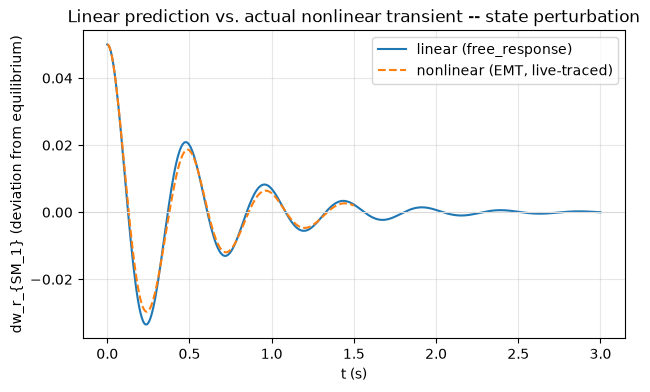

In [86]:
if RUN_EMT_SECTION:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t, x_lin[perturb_idx, :], color="tab:blue", label="linear (free_response)")
    ax.plot(t_eval, nonlinear_trace, color="tab:orange", ls="--", label="nonlinear (EMT, live-traced)")
    ax.axhline(0, color="0.85", lw=0.8)
    ax.set_xlabel("t (s)"); ax.set_ylabel(f"{perturb_name} (deviation from equilibrium)")
    ax.set_title("Linear prediction vs. actual nonlinear transient -- state perturbation")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

### 6b. Perturbing an input, via `u_exo_fn`

A state perturbation moves the *starting point* away from equilibrium
but leaves every reference (`P_ref`, `Q_ref`, ...) exactly where it was;
an input perturbation instead moves the equilibrium itself — the system
starts *at* its own operating point and is then asked to track a new one.

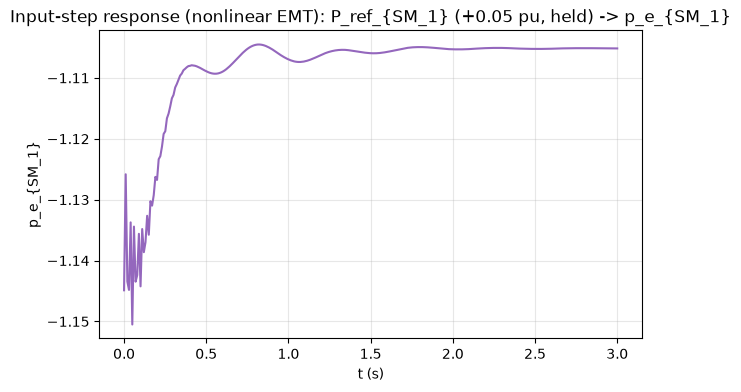

In [87]:
if RUN_EMT_SECTION:
    input_idx = model.input_names.index(sm_input)
    perturbed_u_exo = model.default_u_exo()
    perturbed_u_exo[input_idx] += 0.05
    u_exo_fn = lambda t: perturbed_u_exo  # held constant at the stepped value for all t -- noqa: E731

    t_eval_u = np.linspace(0, 3.0, 300)
    sim_u = simulate(
        model, (0.0, 3.0), u_exo_fn=u_exo_fn, t_eval=t_eval_u,
        method="Radau", rtol=1e-4, atol=1e-6, first_step=1e-8,
    )
    # p_e is an output, not a state -- solve_ivp only returns state
    # trajectories, so recover it from the already-integrated samples.
    _, outputs_u = model.recover_inputs_and_outputs(sim_u.t, sim_u.x, u_exo_fn=u_exo_fn)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t_eval_u, outputs_u[sm_output], color="tab:purple")
    ax.set_xlabel("t (s)"); ax.set_ylabel(sm_output)
    ax.set_title(f"Input-step response (nonlinear EMT): {sm_input} (+0.05 pu, held) -> {sm_output}")
    ax.grid(True, alpha=0.3)
    plt.show()

## 7. Region of attraction

Grid-perturbs the operating point along two states, nonlinearly
simulates each briefly, and classifies whether it's trending back toward
equilibrium. Kept to a small 3x3 grid so this cell finishes quickly — see
`docs/sphinx/modules/stability.md` for why "trend, not fixed-time
convergence" is the right check.

**`t_final` has to match the mode's own damping, not be copied from
another network.** This network's swing mode is damped at ~13% (weaker
than the CIGRE walkthrough's own ~22% example) — at `t_final=0.6s` every
single grid point here reads `False` even though the network is
genuinely stable (confirmed by re-running to `t_final=4.0s`: the same
perturbation's distance-to-baseline drops by two orders of magnitude,
just not yet by 0.6s). `1.5s` is enough headroom for *this* mode; a still
more lightly-damped network would need more again.

In [88]:
if RUN_ROA_SECTION:
    from g2elin_core.stability.roa import RoaAxis, find_state_index, trace_roa_grid

    dw_idx = find_state_index(model, perturb_name)
    gfm_pm_idx = find_state_index(model, "p_m_{GFM_1}")

    axis_x = RoaAxis(perturb_name, dw_idx, np.linspace(-0.05, 0.05, 3))
    axis_y = RoaAxis("p_m_{GFM_1}", gfm_pm_idx, np.linspace(-0.2, 0.2, 3))

    roa = trace_roa_grid(model, axis_x=axis_x, axis_y=axis_y, t_final=1.5, t_early=0.1)
    print("in_roa grid (rows = p_m offset, cols = dw_r offset):")
    print(roa.in_roa)

In [89]:
if RUN_ROA_SECTION:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    colors = np.where(roa.failed, 0.5, np.where(roa.in_roa, 1.0, 0.0))
    ax.imshow(colors, cmap="RdYlGn", vmin=0, vmax=1, origin="lower",
              extent=[axis_x.offsets[0], axis_x.offsets[-1], axis_y.offsets[0], axis_y.offsets[-1]],
              aspect="auto")
    ax.set_xlabel(axis_x.label); ax.set_ylabel(axis_y.label)
    ax.set_title("Region of attraction -- green = recovers, red = diverges")
    plt.show()

## 8. Layer 1 — what pydantic rejects outright

`Network`'s own validators run every time you construct one, so these two
mistakes never even produce an object to inspect -- the exception is
immediate, at `Network(...)` itself.

In [90]:
import copy
from pydantic import ValidationError

bad = net.model_dump()
bad["lines"][0]["to_bus"] = 9999  # references a bus that doesn't exist

try:
    Network(**bad)
except ValidationError as e:
    print("dangling bus reference ->", str(e).splitlines()[0])

dangling bus reference -> 1 validation error for Network


In [91]:
bad = net.model_dump()
bad["der_units"][0]["bus_type"] = "pv"  # was the slack -- now zero slack units

try:
    Network(**bad)
except ValidationError as e:
    print("zero slack units ->", str(e).splitlines()[0])

zero slack units -> 1 validation error for Network


## 9. Layer 2 — what `validate_network()` catches

These are all perfectly *constructible* `Network` objects (every bus
reference resolves, there's exactly one slack) -- pydantic has nothing to
say about them. They're still wrong, and would otherwise surface as a
bare crash deep inside `operating_point.py` or `interconnect/
network_assembly.py` instead of a clear message. `validate_network()` is
what this project uses to catch them proactively -- and it reports *every*
issue in one pass, not just the first one it trips over.

In [92]:
def show(label, issues):
    print(f"--- {label} " + "-" * (40 - len(label)))
    if not issues:
        print("  (no issues)")
    for i in issues:
        print(f"  [{i.severity}] {i.message}")
    print()

In [93]:
# A DER's transformer landing on another DER's own bus, plus a line wired
# directly onto a DER's own bus -- two independent mistakes, both caught
# in the same pass.
broken = net.model_copy(deep=True)
d0, d1 = broken.der_units[0], broken.der_units[1]
for tr in broken.transformers:
    if tr.lv_bus == d1.bus:
        tr.hv_bus = d0.bus  # should be a grid bus, not d0's own bus
broken.lines.append(Line(from_bus=d0.bus, to_bus=d1.bus, r_pu=0.01, x_pu=0.1, b_pu=0.0))

show("DER wired to DER (2 mistakes)", validate_network(broken))

--- DER wired to DER (2 mistakes) -----------
  [error] a line's from_bus (bus 16) is DER unit id=1 (sm)'s own bus -- a DER's own bus may only be reached through its own transformer, never a line directly
  [error] a line's to_bus (bus 17) is DER unit id=2 (sm)'s own bus -- a DER's own bus may only be reached through its own transformer, never a line directly
  [error] DER unit id=2 (sm)'s own transformer connects directly to DER unit id=1 (sm)'s bus (16) instead of a plain grid bus



In [94]:
# Two DER units sharing one bus.
broken = net.model_copy(deep=True)
broken.der_units[1].bus = broken.der_units[0].bus

show("two DERs sharing a bus", validate_network(broken))

--- two DERs sharing a bus ------------------
  [error] DER units id=2 and id=1 are both on bus 16 -- each DER unit needs its own private bus



In [95]:
# A load placed on a DER's own private bus instead of its p_cons_mw field.
broken = net.model_copy(deep=True)
broken.loads.append(Load(bus=broken.der_units[0].bus, p_mw=5.0, q_mvar=1.0, name="stray"))

show("load on a DER's own bus", validate_network(broken))

--- load on a DER's own bus -----------------
  [error] load #11 sits on bus 16, DER unit id=1 (sm)'s own bus -- a DER's own local consumption belongs on the unit itself (its p_cons_mw/q_cons_mvar fields), not as a separate Load on its private bus



In [96]:
# Disconnecting the network: drop every line/transformer touching the
# last grid bus's "far side" of the tree by cutting one line and not
# reconnecting it -- here, brute-force: remove all lines entirely.
broken = net.model_copy(deep=True)
broken.lines = []

show("disconnected network (no lines left)", validate_network(broken))

--- disconnected network (no lines left) ----
  [error] the network isn't fully connected (15 separate groups of buses, sizes [2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]) -- every bus must be reachable from the slack through lines/transformers



In [97]:
# An unsupported slack type -- a GFM slack still powers flow fine, so this
# is a *warning*, not an error: "ok" stays True, but the affected
# capabilities are called out explicitly.
broken = net.model_copy(deep=True)
broken.der_units[0].unit_type = UnitType.GFM
broken.der_units[0].controller = GfmController.DROOP
broken.der_units[0].xd_pu = None

issues = validate_network(broken)
print("ok:", not any(i.severity == "error" for i in issues))
show("gfm slack (warning, not error)", issues)

ok: True
--- gfm slack (warning, not error) ----------
  [warning] the slack unit (id=1) is a gfm, not a synchronous machine or infinite bus -- power flow works, but modal analysis/EMT/ROA don't support a gfm slack yet



## 10. Robustness across many random networks

One clean draw doesn't prove the builder is correct by construction --
running it across many sizes and seeds, validating every single one
before touching power flow or modal analysis, does.

In [98]:
records = []
for seed in range(30):
    r = np.random.default_rng(seed)
    n_grid = int(r.integers(15, 26))  # every draw still >= 15 buses, sizes vary
    n = random_network(r, n_grid_buses=n_grid, name=f"random_seed{seed}")
    issues = validate_network(n)
    ok = not any(i.severity == "error" for i in issues)

    pf_converged = n_states = stable = None
    if ok:
        pf_r = run_power_flow(n)
        pf_converged = pf_r.converged
        if pf_converged:
            sys_r = linearize_network(n, pf_r)
            modal_r = analyze(sys_r.A, sys_r.state_names)
            n_states = sys_r.A.shape[0]
            # 1e-6 tolerance, not a strict "< 0" -- see Section 4's own
            # note: every network here has one eigenvalue structurally
            # pinned near 0 (the "theta problem"), not a real instability.
            stable = bool(np.all(modal_r.eigenvalues.real < 1e-6))

    records.append({
        "seed": seed, "n_grid_buses": n_grid,
        "validate_ok": ok, "n_issues": len(issues),
        "pf_converged": pf_converged, "n_states": n_states, "stable": stable,
    })

df = pd.DataFrame(records)
print(f"{df['validate_ok'].sum()}/{len(df)} validated clean, "
      f"{df['pf_converged'].sum()}/{df['validate_ok'].sum()} of those converged in power flow")
df

30/30 validated clean, 30/30 of those converged in power flow


,seed,n_grid_buses,validate_ok,n_issues,pf_converged,n_states,stable
0,0,24,True,0,True,224,True
1,1,20,True,0,True,198,True
2,2,24,True,0,True,216,True
3,3,23,True,0,True,214,True
4,4,22,True,0,True,204,True
5,5,22,True,0,True,210,True
6,6,19,True,0,True,196,True
7,7,25,True,0,True,228,True
8,8,22,True,0,True,204,True
9,9,19,True,0,True,198,True


## Good practices to take away

- **A DER always gets its own private bus, reached through exactly one
  transformer** — never a `Line`, never shared with another DER, never
  another transformer's `hv_bus`. This one rule drives most of
  `validate_network()`'s checks, because it's the rule a programmatic or
  drag-and-drop builder is most likely to break by accident.
- **A DER's own local consumption is `p_cons_mw`/`q_cons_mvar`, not a
  separate `Load`** on its bus.
- **Exactly one slack DER**, and prefer `sm`/`infinite_bus` for it —
  pydantic enforces "exactly one" unconditionally; `validate_network()`
  additionally warns (not blocks) if it's a type modal/EMT/ROA can't wire
  up yet.
- **Keep the graph connected.** A random spanning tree is a cheap way to
  guarantee this by construction rather than checking for it after the
  fact — and if the topology is meant to be *radial* specifically (a
  distribution feeder, not a meshed transmission network), a spanning
  tree isn't just convenient, it's the definition: no edges beyond it.
- **Give each DER its own connection point.** Nothing in the schema
  requires two DERs to tap different grid buses, but sampling their
  dispatch buses *without replacement* (`rng.choice(..., replace=False)`
  above) keeps the example topologically realistic and easier to reason
  about — two generators electrically coincident at the same point is
  rarely what a real study intends, even though it's schema-valid.
- **Validate before you solve.** `validate_network()` is cheap (no power
  flow needed) and reports every problem at once — call it as a pre-flight
  check on anything you generate or hand-assemble, the same way the web
  UI's network editor calls `POST /api/network/validate` on every edit,
  and the same way `compute_operating_point()` calls it automatically
  before doing any real work.

See `notebooks/tour.ipynb` for the same analysis pipeline exercised
module-by-module on the hand-written presets, and
`docs/sphinx/modules/network.md` for the full account of both validation
layers.